|--- mean concave points <= 0.05
|   |--- worst radius <= 16.83
|   |   |--- area error <= 48.70
|   |   |   |--- worst smoothness <= 0.18
|   |   |   |   |--- class: 1
|   |   |   |--- worst smoothness >  0.18
|   |   |   |   |--- class: 0
|   |   |--- area error >  48.70
|   |   |   |--- texture error <= 1.93
|   |   |   |   |--- class: 1
|   |   |   |--- texture error >  1.93
|   |   |   |   |--- class: 0
|   |--- worst radius >  16.83
|   |   |--- worst texture <= 19.91
|   |   |   |--- class: 1
|   |   |--- worst texture >  19.91
|   |   |   |--- concave points error <= 0.01
|   |   |   |   |--- class: 0
|   |   |   |--- concave points error >  0.01
|   |   |   |   |--- class: 1
|--- mean concave points >  0.05
|   |--- worst concave points <= 0.15
|   |   |--- worst perimeter <= 115.25
|   |   |   |--- mean texture <= 21.06
|   |   |   |   |--- class: 1
|   |   |   |--- mean texture >  21.06
|   |   |   |   |--- class: 0
|   |   |--- worst perimeter >  115.25
|   |   |   |--- cla

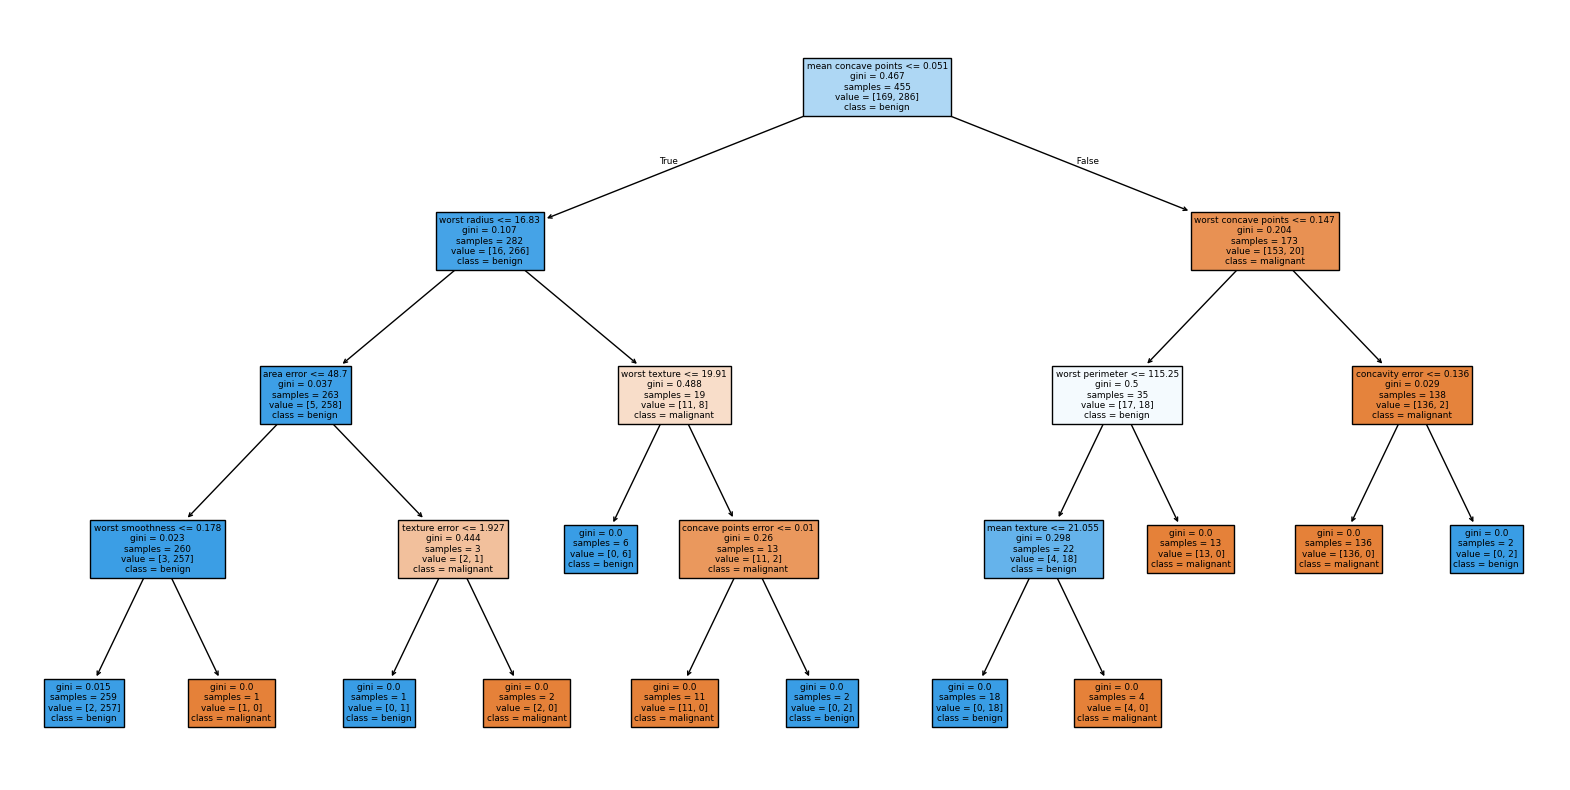

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load and split data
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# Train a decision tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')

# Extract rules as text
print(export_text(dt, feature_names=list(data.feature_names)))

In [9]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from collections import Counter

# Load data
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# Track feature usage across seeds
all_used_features = []

print(f"{'Seed':<10} | {'Root Split Feature':<25} | {'Depth 1 Features'}")
print("-" * 70)

for seed in range(1, 6):
    # Split with a new seed
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed
    )
    
    # Train the tree
    dt = DecisionTreeClassifier(max_depth=4, random_state=seed)
    dt.fit(X_train, y_train)
    
    # Extract all features used in the tree (excluding leaves)
    indices = [i for i in dt.tree_.feature if i != -2] # -2 indicates a leaf node
    unique_features = set(feature_names[i] for i in indices)
    all_used_features.extend(list(unique_features))
    
    # Identify specific important nodes
    root_feature = feature_names[dt.tree_.feature[0]]
    # Get features at the next level (indices 1 and 2 usually)
    depth_1 = [feature_names[dt.tree_.feature[i]] for i in [1, 2] if dt.tree_.feature[i] != -2]
    
    print(f"{seed:<10} | {root_feature:<25} | {', '.join(depth_1)}")

# Summarize Stability
counts = Counter(all_used_features)
print("\n### Feature Stability Summary (Found in X out of 5 trees) ###")
for feature, count in counts.most_common():
    status = "STABLE" if count >= 4 else "UNSTABLE"
    print(f"- {feature:<25}: {count}/5 times ({status})")

Seed       | Root Split Feature        | Depth 1 Features
----------------------------------------------------------------------
1          | worst perimeter           | worst concave points, worst concave points
2          | worst perimeter           | worst concave points, worst concave points
3          | worst concave points      | worst area, area error
4          | worst perimeter           | worst concave points, area error
5          | worst concave points      | worst area, worst perimeter

### Feature Stability Summary (Found in X out of 5 trees) ###
- area error               : 5/5 times (STABLE)
- worst perimeter          : 5/5 times (STABLE)
- worst concave points     : 5/5 times (STABLE)
- mean smoothness          : 3/5 times (UNSTABLE)
- worst smoothness         : 3/5 times (UNSTABLE)
- worst texture            : 3/5 times (UNSTABLE)
- mean texture             : 3/5 times (UNSTABLE)
- worst area               : 3/5 times (UNSTABLE)
- worst concavity          : 2/5 times 

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Train the Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get the top 5 most important features
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top 5 Stable Features in the Forest:")
for i in range(5):
    print(f"{i+1}. {data.feature_names[indices[i]]} ({importances[indices[i]]:.4f})")

Top 5 Stable Features in the Forest:
1. worst area (0.1459)
2. worst concave points (0.1373)
3. mean concave points (0.1067)
4. mean concavity (0.0831)
5. worst perimeter (0.0822)


In [ ]:
# The simplest possible symbolic rule
stump = DecisionTreeClassifier(max_depth=1)
stump.fit(X_train, y_train)

print("The Single Most Powerful Symbolic Rule:")
print(export_text(stump, feature_names=list(data.feature_names)))

The Single Most Powerful Symbolic Rule:
|--- worst concave points <= 0.14
|   |--- class: 1
|--- worst concave points >  0.14
|   |--- class: 0



In [ ]:
import pandas as pd

# Create a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Look at top 2 features, grouped by the class
stats = df.groupby('target')[['worst area', 'worst concave points']].mean()
print(stats)

# Spread of the data
print(df[['worst area', 'worst concave points']].describe())

print("Spread for 'worst area' and 'worst concave points' by class:")
for target in df['target'].unique():
    subset = df[df['target'] == target]
    print(f"\nClass {target} (0=Malignant, 1=Benign):")
    print(subset[['worst area', 'worst concave points']].describe())

         worst area  worst concave points
target                                   
0       1422.286321              0.182237
1        558.899440              0.074444
        worst area  worst concave points
count   569.000000            569.000000
mean    880.583128              0.114606
std     569.356993              0.065732
min     185.200000              0.000000
25%     515.300000              0.064930
50%     686.500000              0.099930
75%    1084.000000              0.161400
max    4254.000000              0.291000
Spread for 'worst area' and 'worst concave points' by class:

Class 0 (0=Malignant, 1=Benign):
        worst area  worst concave points
count   212.000000            212.000000
mean   1422.286321              0.182237
std     597.967743              0.046308
min     508.100000              0.028990
25%     970.300000              0.152750
50%    1303.000000              0.182000
75%    1712.750000              0.210675
max    4254.000000              0.291000

In [ ]:
# Index finder
for i, name in enumerate(data.feature_names):
    print(f"Index {i}: {name}")

# A Symbolic Human Rule
def human_logic_classifier(X):
    preds = []
    for row in X:
        area = row[23]          # worst area
        concave_pts = row[27]   # worst concave points
        
        # Combining observations:
        if area > 800 or concave_pts > 0.12:
            preds.append(0) # Malignant
        else:
            preds.append(1) # Benign
    return np.array(preds)

# Accuracy
from sklearn.metrics import accuracy_score, recall_score

human_preds = human_logic_classifier(X_test)
print(f"Human Accuracy: {accuracy_score(y_test, human_preds):.2%}")
print(f"Human Recall (Catching Malignant): {recall_score(y_test, human_preds, pos_label=0):.2%}")

Index 0: mean radius
Index 1: mean texture
Index 2: mean perimeter
Index 3: mean area
Index 4: mean smoothness
Index 5: mean compactness
Index 6: mean concavity
Index 7: mean concave points
Index 8: mean symmetry
Index 9: mean fractal dimension
Index 10: radius error
Index 11: texture error
Index 12: perimeter error
Index 13: area error
Index 14: smoothness error
Index 15: compactness error
Index 16: concavity error
Index 17: concave points error
Index 18: symmetry error
Index 19: fractal dimension error
Index 20: worst radius
Index 21: worst texture
Index 22: worst perimeter
Index 23: worst area
Index 24: worst smoothness
Index 25: worst compactness
Index 26: worst concavity
Index 27: worst concave points
Index 28: worst symmetry
Index 29: worst fractal dimension
Human Accuracy: 91.23%
Human Recall (Catching Malignant): 95.83%
